# Spike Hunter algorithm focused on Meme coins

Meme index is based on Binance's tags - meme

In [1]:
%pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Evaluation on a single symbol

Found 80 meme symbols:


,id,description,base_asset,quote_asset
0,QTUMBTC,,QTUM,BTC
1,LTCUSDC,,LTC,USDC
2,CHZBTC,,CHZ,BTC
3,OGNBTC,,OGN,BTC
4,SSVETH,,SSV,ETH
...,...,...,...,...
75,AAVEETH,,AAVE,ETH
76,DODOBTC,,DODO,BTC
77,DYDXBTC,,DYDX,BTC
78,SHIBUSDC,,SHIB,USDC


Fetching MEMEUSDC data...
Fetching ADR data...
ADR data fetched successfully
Building features...
Dataset shape: (485, 39)
Date range: 2025-09-06 19:45:00 to 2025-09-11 20:45:00

=== DATA ANALYSIS ===
Price change statistics:
count    485.000000
mean       0.000146
std        0.004541
min       -0.019275
25%       -0.002378
50%        0.000000
75%        0.002731
max        0.018582
Name: price_change, dtype: float64

Volume ratio statistics:
count    485.000000
mean       1.020196
std        0.642318
min        0.016624
25%        0.602148
50%        0.904389
75%        1.290640
max        6.139944
Name: volume_ratio, dtype: float64

Candles with >1% price increase: 10
Candles with >2% price increase: 0

Label distribution: {0: np.int64(478), 1: np.int64(7)}
Spike detection rate: 0.0144

First 10 detected spikes:
              timestamp      open     close  price_change  volume_ratio  \
121 2025-09-08 02:00:00  0.002583  0.002609      0.010066      0.799488   
145 2025-09-08 08:00:00 

/var/folders/jf/bv5tm1xj0gl2z7_bb3q05rgm0000gn/T/ipykernel_24094/1219212548.py:183: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ].fillna(method="bfill")
/Users/carkod/binbot-notebooks/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/carkod/binbot-notebooks/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/carkod/binbot-notebooks/.venv/lib/python3.11/site-pa


=== MODEL EVALUATION ===
Classification Report:
              precision    recall  f1-score   support

           0     0.9897    1.0000    0.9948        96
           1     0.0000    0.0000    0.0000         1

    accuracy                         0.9897        97
   macro avg     0.4948    0.5000    0.4974        97
weighted avg     0.9795    0.9897    0.9846        97


Top 10 Feature Importances:
             feature  importance
6   close_open_ratio    0.173839
0       price_change    0.167812
14      close_to_low    0.148510
1   price_change_abs    0.096745
2      body_size_pct    0.093853
12         range_pct    0.048220
13     close_to_high    0.041044
7       price_zscore    0.029998
4   lower_wick_ratio    0.029436
11        momentum_5    0.027941


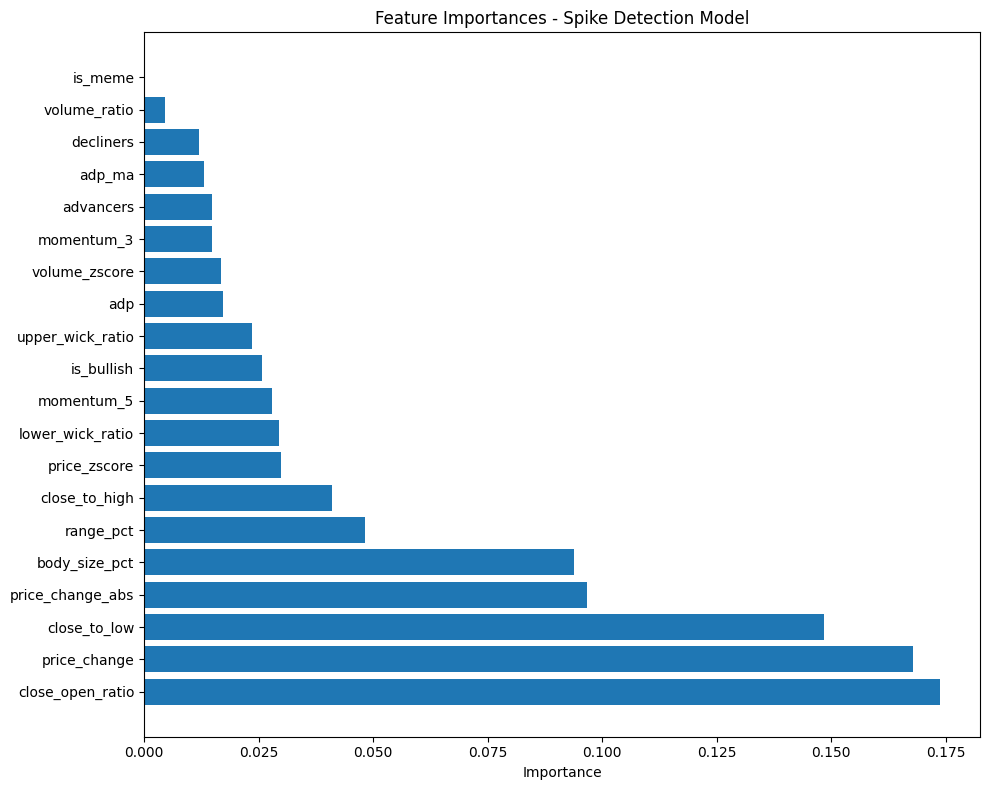


=== PLOTTING RESULTS ===
Plotting 7 detected spikes


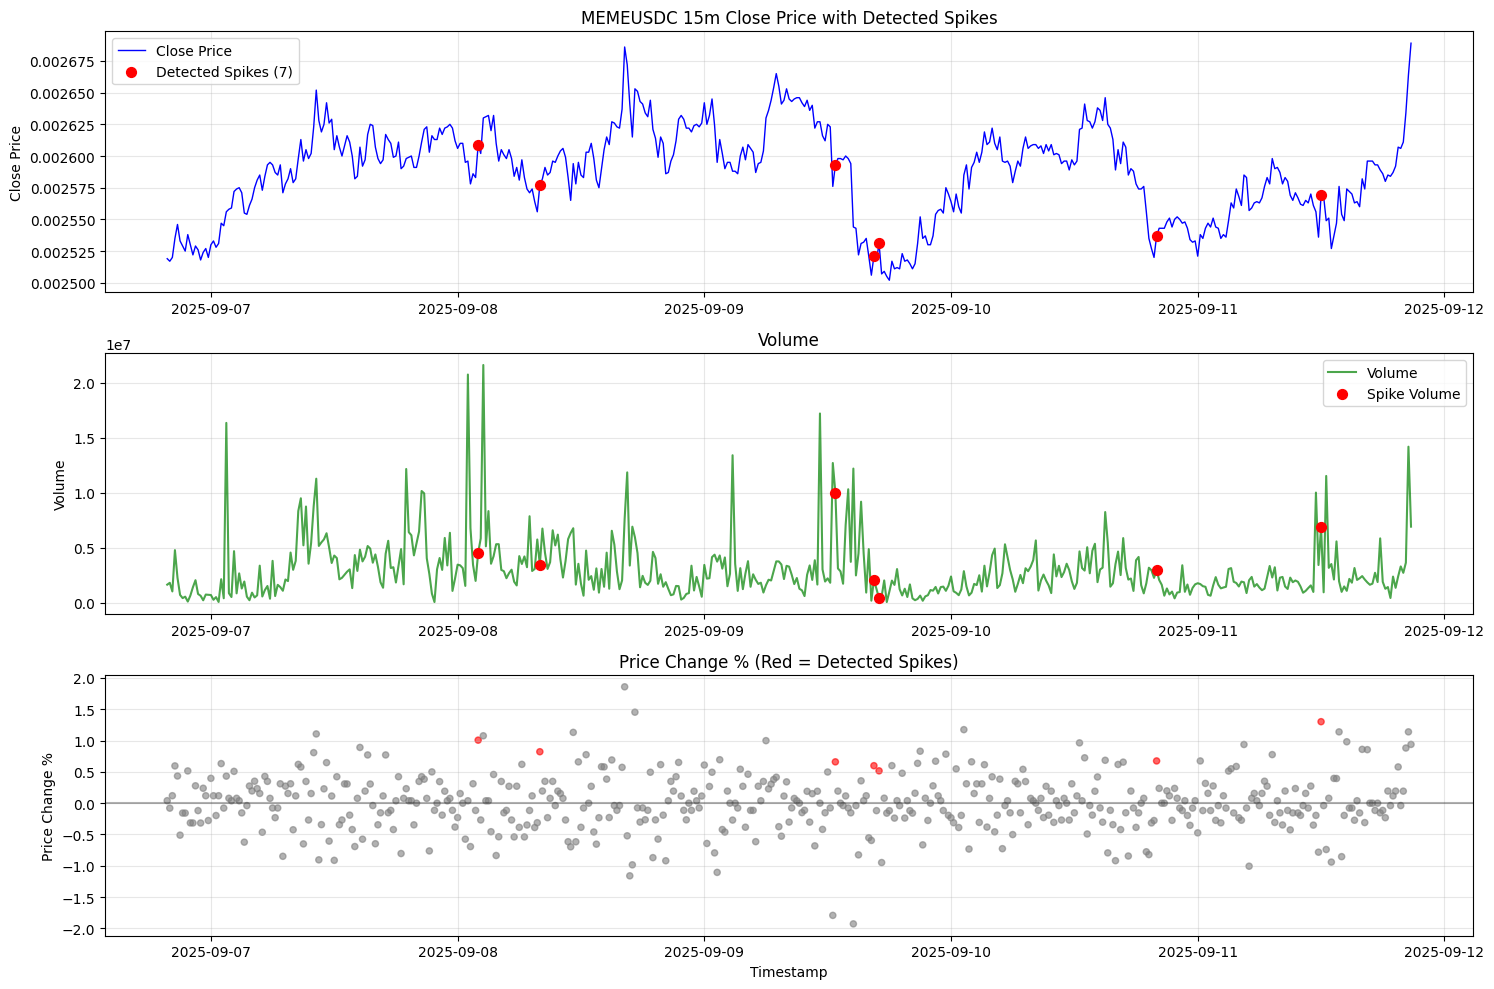

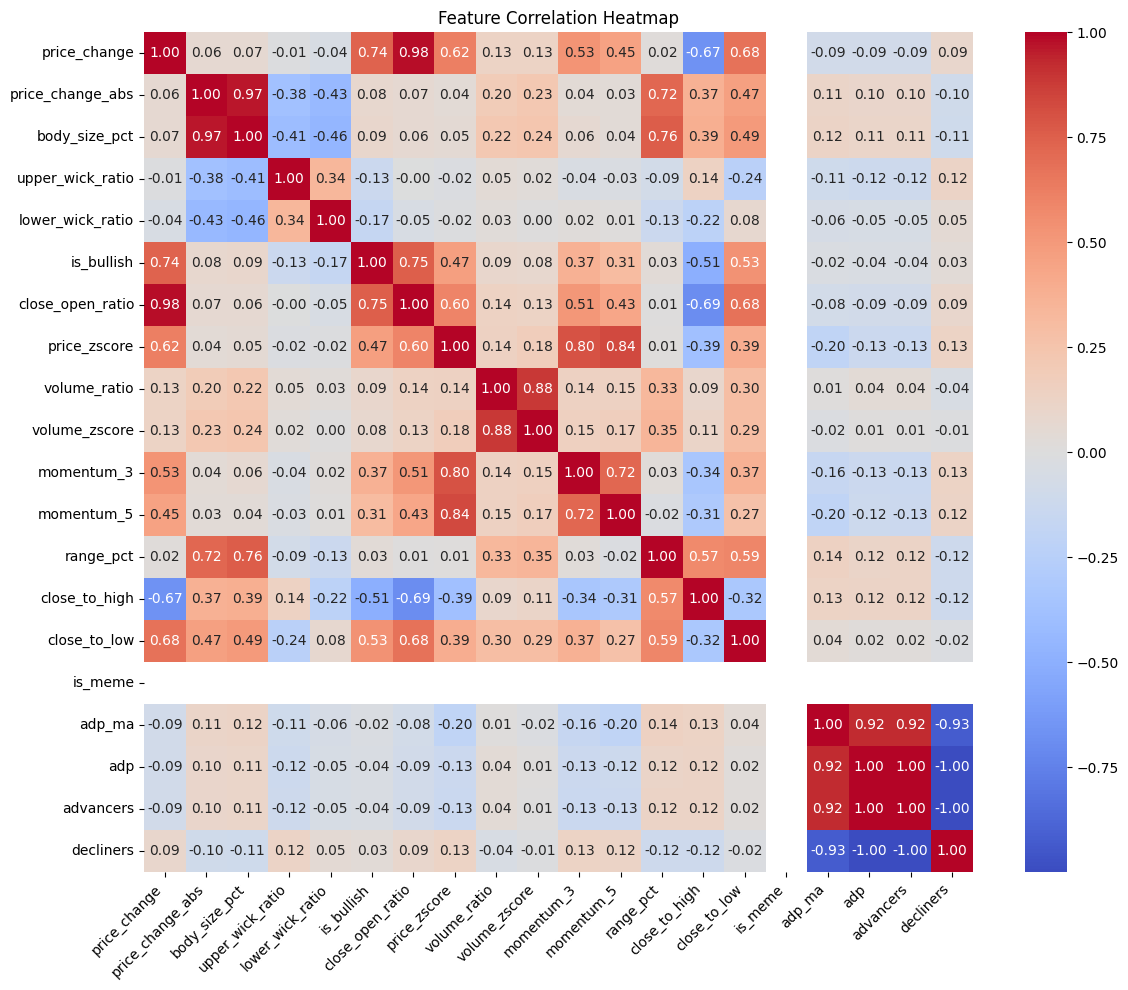

In [2]:
import pandas as pd
import numpy as np
import requests
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import joblib
import seaborn as sns  # Added for correlation heatmap

# Fetch all symbols from the API
url = "https://api.terminal.binbot.in/symbols"
resp = requests.get(url)
data = resp.json()["data"]

# Filter for symbols where any asset_indices has id == 'meme'
meme_symbols = [
    sym["id"] for sym in data if any(idx.get("id") == "meme" for idx in sym.get("asset_indices", []))
]

# Convert to DataFrame for easy viewing
meme_symbols_df = pd.DataFrame([sym for sym in data if sym["id"] in meme_symbols])
print(f"Found {len(meme_symbols_df)} meme symbols:")
display(meme_symbols_df[["id", "description", "base_asset", "quote_asset"]])

symbol = "MEMEUSDC"

# Set fixed thresholds for both training and production (example: 0.02 for price, 2.0 for volume)
FIXED_PRICE_THRESHOLD = 0.02
FIXED_VOLUME_THRESHOLD = 2.0

# --- Step 1: Fetch 15m candles from Binance ---
def fetch_binance_klines(symbol="IDEXUSDC", interval="15m", limit=500, end_time=None):
    url = "https://api.binance.com/api/v3/klines"
    params = {"symbol": symbol, "interval": interval, "limit": limit}
    if end_time:
        params["endTime"] = end_time
    resp = requests.get(url, params=params)
    data = resp.json()
    df = pd.DataFrame(
        data,
        columns=[
            "open_time",
            "open",
            "high",
            "low",
            "close",
            "volume",
            "close_time",
            "qav",
            "num_trades",
            "taker_base",
            "taker_quote",
            "ignore",
        ],
    )
    df = df[["open_time", "open", "high", "low", "close", "volume"]].astype(float)
    df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
    df = df.sort_values("timestamp").reset_index(drop=True)
    return df

# --- Step 2: Fetch ADR data ---
def fetch_adr_series(size=500):
    url = f"https://api.terminal.binbot.in/charts/adr-series?size={size}"
    resp = requests.get(url)
    j = resp.json()
    df_adr = pd.DataFrame(
        {
            "timestamp": pd.to_datetime(j["data"]["timestamp"]),
            "adp_ma": j["data"]["adp_ma"],
            "advancers": j["data"]["advancers"],
            "decliners": j["data"]["decliners"],
            "adp": j["data"]["adp"],
            "total_volume": j["data"]["total_volume"],
        }
    )
    return df_adr

# --- Step 3: Spike labeling with multiple detection methods ---
def label_spike_patterns(
    df,
    price_thresh=0.010,
    vol_ratio_thresh=1,
    window=12,
    momentum_thresh=0.01,
    rsi_oversold=30,
    use_adr_filter=False,
    adp_col="adp",
    adp_thresh=0.5,
):
    """
    Spike detection with multiple methods:
    1. Price + Volume spike detection
    2. Momentum-based detection
    3. RSI oversold reversal detection
    4. Optional ADR filtering
    """
    labels = []

    # Calculate RSI
    df = calculate_rsi(df, window=14)

    for i in range(len(df)):
        if i < window:
            labels.append(0)
            continue

        label = 0

        # Method 1: Traditional price + volume spike
        prev_close = df.loc[i - 1, "close"]
        curr_close = df.loc[i, "close"]
        price_change = (curr_close - prev_close) / prev_close

        # Use smaller rolling window for volume comparison with microcaps
        vol_window = min(window, i)
        avg_vol = df.loc[max(0, i - vol_window) : i - 1, "volume"].mean()
        vol_ratio = df.loc[i, "volume"] / (avg_vol + 1e-6)

        if price_change > price_thresh and vol_ratio > vol_ratio_thresh:
            label = 1

        # Method 2: Momentum-based detection (consecutive positive moves)
        if not label and i >= 3:  # Reduced from window requirement
            recent_changes = df.loc[max(0, i - 3) : i, "price_change"]
            if (
                len(recent_changes) >= 3
                and (recent_changes > momentum_thresh).sum() >= 2
            ):
                total_momentum = recent_changes.sum()
                if total_momentum > price_thresh:
                    label = 1

        # Method 3: RSI oversold reversal
        if not label and i >= 14:  # RSI requires 14 periods minimum
            prev_rsi = df.loc[i - 1, "rsi"]
            curr_rsi = df.loc[i, "rsi"]
            if (
                prev_rsi < rsi_oversold
                and curr_rsi > prev_rsi + 5
                and price_change > 0.005
            ):
                label = 1

        # Optional ADR filter (only apply if use_adr_filter is True)
        if label and use_adr_filter:
            adp_val = df.loc[i, adp_col] if adp_col in df.columns else 0.5
            if pd.isna(adp_val) or adp_val >= adp_thresh:
                label = 0

        labels.append(label)

    df = df.copy()
    df["label"] = labels
    return df

def calculate_rsi(df, window=14):
    """Calculate RSI indicator"""
    df = df.copy()
    delta = df["close"].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    df["rsi"] = 100 - (100 / (1 + rs))
    return df

# --- Step 4: Enhanced feature engineering ---
def add_enhanced_features(df_price, df_adr=None, window=12):
    df = df_price.copy()
    df = df.sort_values("timestamp").reset_index(drop=True)

    # Adapt window size for small datasets
    effective_window = min(window, len(df) // 8)  # More conservative for microcaps
    if effective_window < 3:
        effective_window = 3  # Absolute minimum

    # Merge ADR data if available
    if df_adr is not None:
        df_adr = df_adr.sort_values("timestamp").reset_index(drop=True)
        df = pd.merge_asof(df, df_adr, on="timestamp", direction="backward")
        df[["adp", "adp_ma", "advancers", "decliners", "total_volume"]] = df[
            ["adp", "adp_ma", "advancers", "decliners", "total_volume"]
        ].fillna(method="bfill")

    # Basic price features
    df["price_change"] = df["close"].pct_change()
    df["price_change_abs"] = df["price_change"].abs()

    # Candle features
    df["body_size"] = abs(df["close"] - df["open"])
    df["body_size_pct"] = df["body_size"] / df["open"]
    df["upper_wick"] = df["high"] - df[["close", "open"]].max(axis=1)
    df["lower_wick"] = df[["close", "open"]].min(axis=1) - df["low"]
    df["upper_wick_ratio"] = df["upper_wick"] / (df["body_size"] + 1e-6)
    df["lower_wick_ratio"] = df["lower_wick"] / (df["body_size"] + 1e-6)
    df["total_range"] = df["high"] - df["low"]
    df["range_pct"] = df["total_range"] / df["open"]

    # Trend and momentum features
    df["is_bullish"] = (df["close"] > df["open"]).astype(int)
    df["close_open_ratio"] = (df["close"] - df["open"]) / (df["open"] + 1e-6)

    # Rolling features - use effective window
    df["price_ma"] = df["close"].rolling(window=effective_window).mean()
    df["price_std"] = df["close"].rolling(window=effective_window).std()
    df["price_zscore"] = (df["close"] - df["price_ma"]) / (df["price_std"] + 1e-6)

    # Volume features
    df["volume_ma"] = df["volume"].rolling(window=effective_window).mean()
    df["volume_ratio"] = df["volume"] / (df["volume_ma"] + 1e-6)
    df["volume_zscore"] = (df["volume"] - df["volume_ma"]) / (
        df["volume"].rolling(window=effective_window).std() + 1e-6
    )

    # Add new volume percentile feature
    df["volume_percentile"] = (
        df["volume"].rolling(window=effective_window * 2).rank(pct=True)
    )

    # Momentum indicators
    df["momentum_3"] = df["close"].pct_change(3)
    df["momentum_5"] = df["close"].pct_change(5)

    # High/Low features
    df["high_low_ratio"] = df["high"] / df["low"]
    df["close_to_high"] = (df["high"] - df["close"]) / (df["high"] + 1e-6)
    df["close_to_low"] = (df["close"] - df["low"]) / (df["close"] + 1e-6)

    df = df.dropna().reset_index(drop=True)

    # Apply more conservative spike labeling with higher thresholds
    df = label_spike_patterns(
        df,
        price_thresh=FIXED_PRICE_THRESHOLD,
        vol_ratio_thresh=FIXED_VOLUME_THRESHOLD,
        window=effective_window,
        momentum_thresh=0.015,
        use_adr_filter=False,
    )

    return df

# --- Data fetching and analysis ---
print(f"Fetching {symbol} data...")
df_price = fetch_binance_klines(
    symbol, interval="15m", limit=500
)  # Keep original limit for microcaps

print("Fetching ADR data...")
try:
    df_adr = fetch_adr_series(size=500)
    print("ADR data fetched successfully")
except Exception as e:
    print(f"Failed to fetch ADR data: {e}")
    df_adr = None

print("Building features...")
df = add_enhanced_features(df_price, df_adr, window=8)  # Reduced window for microcaps

# --- Add is_meme feature ---
df["is_meme"] = 1 if symbol in meme_symbols else 0

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

# Analyze the data before training
print("\n=== DATA ANALYSIS ===")
print(f"Price change statistics:")
print(df["price_change"].describe())
print(f"\nVolume ratio statistics:")
print(df["volume_ratio"].describe())

# Check for actual spikes in the data
upward_moves = df[df["price_change"] > 0.01]  # 1%+ moves
print(f"\nCandles with >1% price increase: {len(upward_moves)}")
large_moves = df[df["price_change"] > 0.02]  # 2%+ moves
print(f"Candles with >2% price increase: {len(large_moves)}")

# Show label distribution
label_counts = np.bincount(df["label"].astype(int))
print(f"\nLabel distribution: {dict(enumerate(label_counts))}")
print(
    f"Spike detection rate: {label_counts[1] / (label_counts[0] + label_counts[1]):.4f}"
)

# Show some examples of detected spikes
if label_counts[1] > 0:
    spike_examples = df[df["label"] == 1][
        ["timestamp", "open", "close", "price_change", "volume_ratio", "body_size_pct"]
    ].head(10)
    print(f"\nFirst 10 detected spikes:")
    print(spike_examples)

# --- Model Training ---
feature_cols = [
    "price_change",
    "price_change_abs",
    "body_size_pct",
    "upper_wick_ratio",
    "lower_wick_ratio",
    "is_bullish",
    "close_open_ratio",
    "price_zscore",
    "volume_ratio",
    "volume_zscore",
    "momentum_3",
    "momentum_5",
    "range_pct",
    "close_to_high",
    "close_to_low",
    "is_meme",
]

# Add ADR features if available
if df_adr is not None and "adp" in df.columns:
    feature_cols.extend(["adp_ma", "adp", "advancers", "decliners"])

# Only use features that exist in the dataframe
available_features = [col for col in feature_cols if col in df.columns]
print(f"\nUsing features: {available_features}")

X = df[available_features]
y = df["label"]

print(f"\nFinal label counts: {np.bincount(y.astype(int)) if len(y) > 0 else 'empty'}")

if len(np.unique(y)) < 2:
    print("Not enough positive examples found. Consider:")
    print("1. Lowering price_thresh (currently 0.015)")
    print("2. Lowering vol_ratio_thresh (currently 1.5)")
    print("3. Adding more data")
    print("4. Checking if OMNI/USDC has sufficient volatility in this period")
else:
    # Handle class imbalance
    from sklearn.utils.class_weight import compute_class_weight

    class_weights = compute_class_weight("balanced", classes=np.unique(y), y=y)
    class_weight_dict = dict(zip(np.unique(y), class_weights))
    print(f"Using class weights: {class_weight_dict}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    clf = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
    )
    clf.fit(X_train, y_train)

    # --- Evaluation ---
    y_pred = clf.predict(X_test)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]

    print("\n=== MODEL EVALUATION ===")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    # Save model
    import os

    os.makedirs("./checkpoints", exist_ok=True)
    joblib.dump(clf, "./checkpoints/spikehunter_model_meme.pkl")

    # Feature importance
    importances = clf.feature_importances_
    feature_importance_df = pd.DataFrame(
        {"feature": available_features, "importance": importances}
    ).sort_values("importance", ascending=False)

    print(f"\nTop 10 Feature Importances:")
    print(feature_importance_df.head(10))

    # Plot feature importance
    plt.figure(figsize=(10, 8))
    plt.barh(feature_importance_df["feature"], feature_importance_df["importance"])
    plt.title("Feature Importances - Spike Detection Model")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

# Add plotting code at the end for immediate visualization
print("\n=== PLOTTING RESULTS ===")
# Plot Binance klines and highlight detected spikes
plt.figure(figsize=(15, 10))

# Subplot 1: Price with spikes
plt.subplot(3, 1, 1)
plt.plot(df["timestamp"], df["close"], label="Close Price", color="blue", linewidth=1)
spike_indices = df.index[df["label"] == 1]
if len(spike_indices) > 0:
    plt.scatter(
        df.loc[spike_indices, "timestamp"],
        df.loc[spike_indices, "close"],
        color="red",
        label=f"Detected Spikes ({len(spike_indices)})",
        zorder=5,
        s=50,
    )
    print(f"Plotting {len(spike_indices)} detected spikes")
else:
    print("No spikes detected to plot")

plt.title(f"{symbol} 15m Close Price with Detected Spikes")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Volume with spikes
plt.subplot(3, 1, 2)
plt.plot(df["timestamp"], df["volume"], label="Volume", color="green", alpha=0.7)
if len(spike_indices) > 0:
    plt.scatter(
        df.loc[spike_indices, "timestamp"],
        df.loc[spike_indices, "volume"],
        color="red",
        label="Spike Volume",
        zorder=5,
        s=50,
    )
plt.title("Volume")
plt.ylabel("Volume")
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 3: Price change percentage
plt.subplot(3, 1, 3)
colors = ["red" if x == 1 else "gray" for x in df["label"]]
plt.scatter(df["timestamp"], df["price_change"] * 100, c=colors, alpha=0.6, s=20)
plt.axhline(y=0, color="black", linestyle="-", alpha=0.3)
plt.title("Price Change % (Red = Detected Spikes)")
plt.xlabel("Timestamp")
plt.ylabel("Price Change %")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Correlation Heatmap ---
plt.figure(figsize=(12, 10))
correlation_matrix = df[available_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Aggregating data for up to 10 meme coins...
[1/10] Fetching QTUMBTC...


/var/folders/jf/bv5tm1xj0gl2z7_bb3q05rgm0000gn/T/ipykernel_24094/1219212548.py:183: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ].fillna(method="bfill")


[2/10] Fetching LTCUSDC...


/var/folders/jf/bv5tm1xj0gl2z7_bb3q05rgm0000gn/T/ipykernel_24094/1219212548.py:183: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ].fillna(method="bfill")


[3/10] Fetching CHZBTC...


...

[9/10] Fetching HEIUSDC...


/var/folders/jf/bv5tm1xj0gl2z7_bb3q05rgm0000gn/T/ipykernel_24094/1219212548.py:183: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ].fillna(method="bfill")


[10/10] Fetching HUMAUSDC...


/var/folders/jf/bv5tm1xj0gl2z7_bb3q05rgm0000gn/T/ipykernel_24094/1219212548.py:183: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ].fillna(method="bfill")


Combined meme group dataset shape: (4850, 40)
Symbols included: ['QTUMBTC' 'LTCUSDC' 'CHZBTC' 'OGNBTC' 'SSVETH' 'UNIETH' 'AVAXUSDC'
 'CHZUSDC' 'HEIUSDC' 'HUMAUSDC']

Using features: ['price_change', 'price_change_abs', 'body_size_pct', 'upper_wick_ratio', 'lower_wick_ratio', 'is_bullish', 'close_open_ratio', 'price_zscore', 'volume_ratio', 'volume_zscore', 'momentum_3', 'momentum_5', 'range_pct', 'close_to_high', 'close_to_low', 'adp_ma', 'adp', 'advancers', 'decliners']

Final label counts: [4787   63]
Using class weights: {np.int64(0): np.float64(0.5065803217046166), np.int64(1): np.float64(38.492063492063494)}

=== MEME GROUP MODEL EVALUATION ===
Classification Report:
              precision    recall  f1-score   support

           0     0.9958    0.9948    0.9953       957
           1     0.6429    0.6923    0.6667        13

    accuracy                         0.9907       970
   macro avg     0.8193    0.8435    0.8310       970
weighted avg     0.9911    0.9907    0.9909    

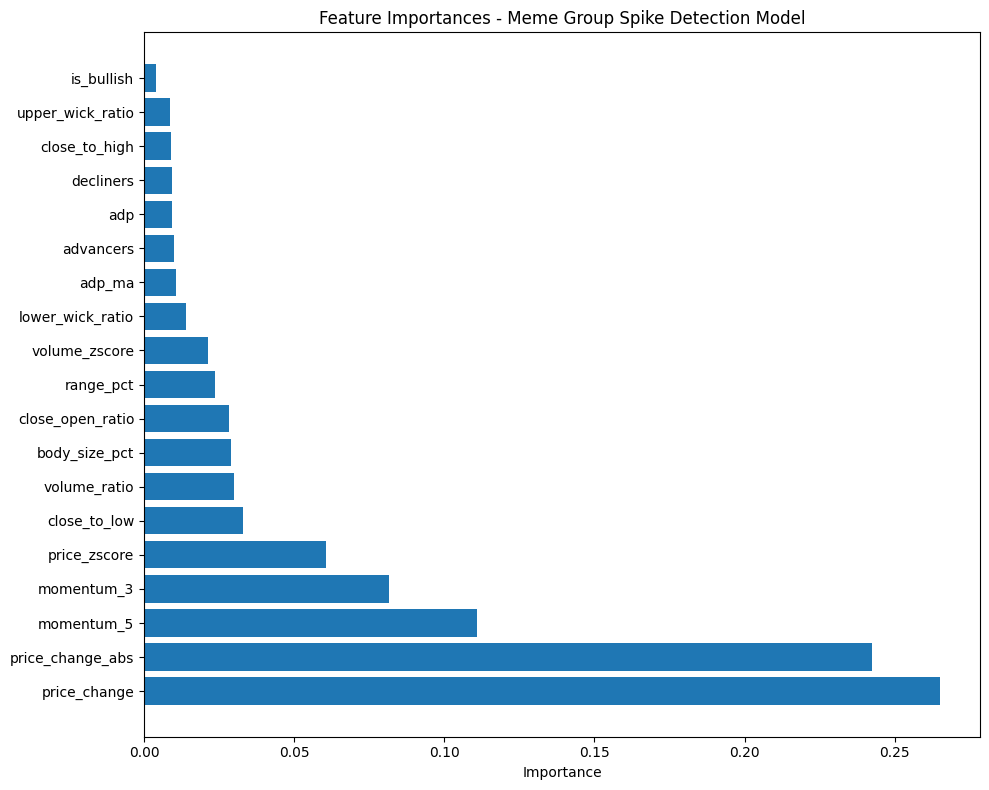

In [3]:
# --- Meme Group Analysis: Aggregate all meme coins and train a group model ---

import time

all_meme_dfs = []

max_symbols = 10  # Limit for demo; increase for full analysis

print(f"Aggregating data for up to {max_symbols} meme coins...")

for i, sym_id in enumerate(meme_symbols[:max_symbols]):
    try:
        print(f"[{i+1}/{max_symbols}] Fetching {sym_id}...")
        df_price = fetch_binance_klines(sym_id, interval="15m", limit=500)
        df_adr = None
        try:
            df_adr = fetch_adr_series(size=500)
        except Exception as e:
            pass
        df = add_enhanced_features(df_price, df_adr, window=8)
        df["symbol"] = sym_id
        df["is_meme"] = 1
        all_meme_dfs.append(df)
        time.sleep(0.2)  # Be nice to the API
    except Exception as e:
        print(f"Failed for {sym_id}: {e}")

if not all_meme_dfs:
    print("No meme coin data could be aggregated.")
else:
    meme_group_df = pd.concat(all_meme_dfs, ignore_index=True)
    print(f"Combined meme group dataset shape: {meme_group_df.shape}")
    print(f"Symbols included: {meme_group_df['symbol'].unique()}")

    # Model training for meme group
    feature_cols = [
        "price_change", "price_change_abs", "body_size_pct", "upper_wick_ratio", "lower_wick_ratio",
        "is_bullish", "close_open_ratio", "price_zscore", "volume_ratio", "volume_zscore",
        "momentum_3", "momentum_5", "range_pct", "close_to_high", "close_to_low"
    ]
    # Add ADR features if available
    adr_cols = ["adp_ma", "adp", "advancers", "decliners"]
    for col in adr_cols:
        if col in meme_group_df.columns:
            feature_cols.append(col)
    # Only use features that exist in the dataframe
    available_features = [col for col in feature_cols if col in meme_group_df.columns]
    print(f"\nUsing features: {available_features}")

    X = meme_group_df[available_features]
    y = meme_group_df["label"]

    print(f"\nFinal label counts: {np.bincount(y.astype(int)) if len(y) > 0 else 'empty'}")

    if len(np.unique(y)) < 2:
        print("Not enough positive examples found in meme group.")
    else:
        from sklearn.utils.class_weight import compute_class_weight
        class_weights = compute_class_weight("balanced", classes=np.unique(y), y=y)
        class_weight_dict = dict(zip(np.unique(y), class_weights))
        print(f"Using class weights: {class_weight_dict}")

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=42
        )
        clf = RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
        )
        clf.fit(X_train, y_train)

        # --- Evaluation ---
        y_pred = clf.predict(X_test)
        y_pred_proba = clf.predict_proba(X_test)[:, 1]
        print("\n=== MEME GROUP MODEL EVALUATION ===")
        print("Classification Report:")
        print(classification_report(y_test, y_pred, digits=4))

        # Feature importance
        importances = clf.feature_importances_
        feature_importance_df = pd.DataFrame(
            {"feature": available_features, "importance": importances}
        ).sort_values("importance", ascending=False)
        print(f"\nTop 10 Feature Importances (Meme Group):")
        print(feature_importance_df.head(10))

        # Plot feature importance
        plt.figure(figsize=(10, 8))
        plt.barh(feature_importance_df["feature"], feature_importance_df["importance"])
        plt.title("Feature Importances - Meme Group Spike Detection Model")
        plt.xlabel("Importance")
        plt.tight_layout()
        plt.show()



=== Price Correlation Matrix (Close Prices) ===


,QTUMBTC,LTCUSDC,CHZBTC,OGNBTC,SSVETH,UNIETH,AVAXUSDC,CHZUSDC,HEIUSDC,HUMAUSDC
QTUMBTC,1.000000,-0.534854,-0.301315,-0.150290,-0.347817,-0.606990,-0.947808,-0.719055,-0.582699,-0.491206
LTCUSDC,-0.534854,1.000000,-0.158913,-0.222468,0.028598,0.322637,0.666802,0.220861,0.399554,0.357022
CHZBTC,-0.301315,-0.158913,1.000000,0.468810,0.622917,0.574590,0.231179,0.717129,0.265853,0.494173
OGNBTC,-0.150290,-0.222468,0.468810,1.000000,0.379543,0.458101,0.109207,0.547004,0.233329,0.480816
SSVETH,-0.347817,0.028598,0.622917,0.379543,1.000000,0.475191,0.245035,0.646171,0.344043,0.583769
UNIETH,-0.606990,0.322637,0.574590,0.458101,0.475191,1.000000,0.648024,0.840166,0.475629,0.689423
AVAXUSDC,-0.947808,0.666802,0.231179,0.109207,0.245035,0.648024,1.000000,0.680939,0.510838,0.497938
CHZUSDC,-0.719055,0.220861,0.717129,0.547004,0.646171,0.840166,0.680939,1.000000,0.607467,0.768266
HEIUSDC,-0.582699,0.399554,0.265853,0.233329,0.344043,0.475629,0.510838,0.607467,1.000000,0.581208
HUMAUSDC,-0.491206,0.357022,0.494173,0.480816,0.583769,0.689423,0.497938,0.768266,0.581208,1.000000


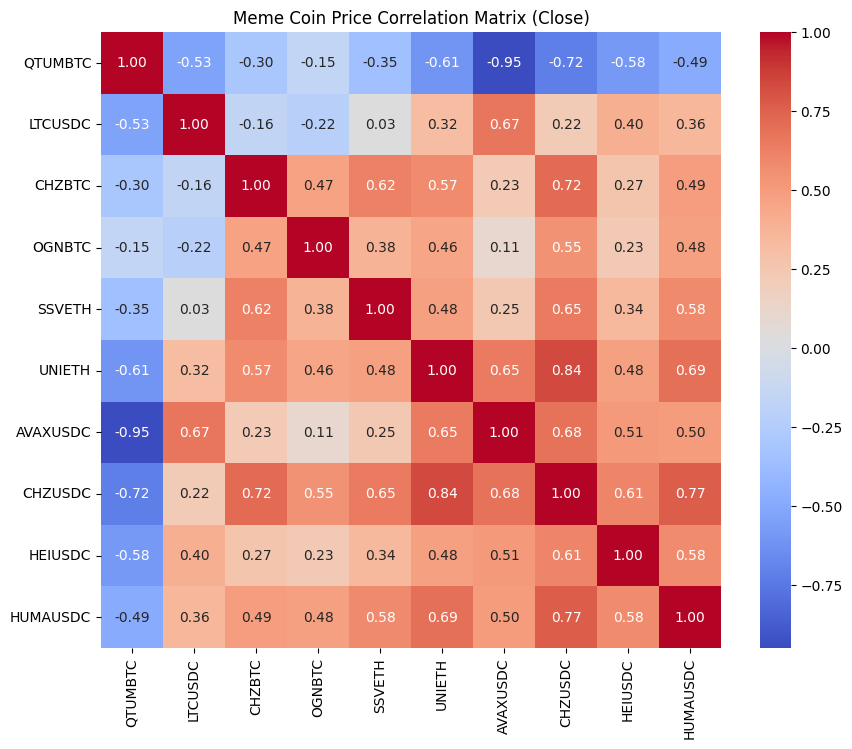

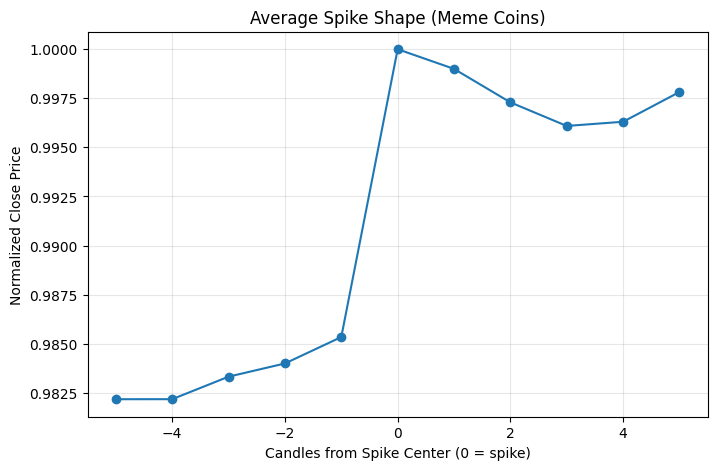

In [4]:
# --- Meme Group: Price Correlation and Spike Shape Analysis ---

import seaborn as sns

# 1. Price correlation matrix for meme coins
if not all_meme_dfs:
    print("No meme coin data to analyze correlations.")
else:
    # Build a wide DataFrame: each symbol's close price as a column
    price_wide = {}
    for df in all_meme_dfs:
        sym = df['symbol'].iloc[0]
        # Reindex to timestamp for alignment
        price_wide[sym] = df.set_index('timestamp')['close']
    price_wide_df = pd.DataFrame(price_wide)
    # Drop columns with too many NaNs
    price_wide_df = price_wide_df.dropna(axis=1, thresh=int(0.5*len(price_wide_df)))
    corr = price_wide_df.corr()
    print("\n=== Price Correlation Matrix (Close Prices) ===")
    display(corr)
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Meme Coin Price Correlation Matrix (Close)")
    plt.show()

# 2. Average spike shape visualization
if not all_meme_dfs:
    print("No meme coin data to analyze spike shapes.")
else:
    window = 5  # Number of candles before/after spike
    aligned_spikes = []
    for df in all_meme_dfs:
        spikes = df[df['label'] == 1].index
        for idx in spikes:
            if idx > window and idx+window < len(df):
                segment = df.iloc[idx-window:idx+window+1]["close"].values
                # Normalize to start at 1
                segment = segment / segment[window]
                aligned_spikes.append(segment)
    if aligned_spikes:
        avg_spike = np.mean(aligned_spikes, axis=0)
        plt.figure(figsize=(8,5))
        plt.plot(range(-window, window+1), avg_spike, marker='o')
        plt.title("Average Spike Shape (Meme Coins)")
        plt.xlabel("Candles from Spike Center (0 = spike)")
        plt.ylabel("Normalized Close Price")
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print("No spikes found to analyze average spike shape.")


# Production Spike Hunter
Unified spike detection system for cryptocurrency trading.
- Full-featured production analysis (detailed stats, multiple detection methods)
- Standalone last spike detection (recent spike reporting)
- Dynamic thresholding, top-N stats, volatility reporting, and advanced plotting

In [5]:
import pandas as pd
import numpy as np
import requests
from typing import Optional, Dict, Tuple
import warnings
import matplotlib.pyplot as plt
import joblib

warnings.filterwarnings("ignore")

class SpikeHunter:
    """
    Unified spike detection system for cryptocurrency assets.
    Features:
    - Multiple detection algorithms (price+volume, momentum, RSI reversal, ML classifier)
    - Configurable sensitivity levels
    - Robust error handling
    - Performance optimized
    - Detailed summary and last spike reporting
    - Dynamic thresholding and advanced stats
    - ML-based spike prediction (RandomForest)
    """
    def __init__(
        self,
        model_path: str,
        momentum_threshold: float = 0.012,
        window: int = 12,
        rsi_oversold: int = 30,
        price_threshold: float = None,
        volume_threshold: float = None,
    ):
        self.momentum_threshold = momentum_threshold
        self.window = window
        self.rsi_oversold = rsi_oversold
        self.model = joblib.load(model_path)
        # If thresholds are provided, use them; otherwise, will be set dynamically
        self.price_threshold = price_threshold
        self.volume_threshold = volume_threshold

    def fetch_market_data(
        self,
        symbol: str,
        interval: str = "15m",
        limit: int = 500,
        end_time: Optional[int] = None,
    ) -> pd.DataFrame:
        try:
            url = "https://api.binance.com/api/v3/klines"
            params = {"symbol": symbol, "interval": interval, "limit": limit}
            if end_time:
                params["endTime"] = end_time
            response = requests.get(url, params=params, timeout=10)
            response.raise_for_status()
            data = response.json()
            df = pd.DataFrame(
                data,
                columns=[
                    "open_time", "open", "high", "low", "close", "volume",
                    "close_time", "qav", "num_trades", "taker_base", "taker_quote", "ignore"
                ],
            )
            numeric_cols = ["open", "high", "low", "close", "volume"]
            df[numeric_cols] = df[numeric_cols].astype(float)
            df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
            df = df[["timestamp", "open", "high", "low", "close", "volume"]]
            return df.sort_values("timestamp").reset_index(drop=True)
        except Exception as e:
            raise Exception(f"Failed to fetch market data for {symbol}: {str(e)}")

    def calculate_rsi(self, prices: pd.Series, window: int = 14) -> pd.Series:
        delta = prices.diff()
        gain = delta.where(delta > 0, 0).rolling(window=window, min_periods=1).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=window, min_periods=1).mean()
        rs = gain / (loss + 1e-10)
        return 100 - (100 / (1 + rs))

    def _add_all_features(self, df: pd.DataFrame) -> pd.DataFrame:
        # Basic price features
        df["price_change"] = df["close"].pct_change()
        df["price_change_abs"] = df["price_change"].abs()
        df["body_size"] = abs(df["close"] - df["open"])
        df["body_size_pct"] = df["body_size"] / df["open"]
        df["upper_wick"] = df["high"] - df[["close", "open"]].max(axis=1)
        df["lower_wick"] = df[["close", "open"]].min(axis=1) - df["low"]
        df["upper_wick_ratio"] = df["upper_wick"] / (df["body_size"] + 1e-6)
        df["lower_wick_ratio"] = df["lower_wick"] / (df["body_size"] + 1e-6)
        df["total_range"] = df["high"] - df["low"]
        df["range_pct"] = df["total_range"] / df["open"]
        df["is_bullish"] = (df["close"] > df["open"]).astype(int)
        df["close_open_ratio"] = (df["close"] - df["open"]) / (df["open"] + 1e-6)
        # Rolling features
        effective_window = min(self.window, len(df) // 4)
        if effective_window < 3:
            effective_window = 3
        df["price_ma"] = df["close"].rolling(window=effective_window).mean()
        df["price_std"] = df["close"].rolling(window=effective_window).std()
        df["price_zscore"] = (df["close"] - df["price_ma"]) / (df["price_std"] + 1e-6)
        # Volume features
        df["volume_ma"] = df["volume"].rolling(window=effective_window).mean()
        df["volume_ratio"] = df["volume"] / (df["volume_ma"] + 1e-6)
        df["volume_zscore"] = (df["volume"] - df["volume_ma"]) / (df["volume"].rolling(window=effective_window).std() + 1e-6)
        # Momentum indicators
        df["momentum_3"] = df["close"].pct_change(3)
        df["momentum_5"] = df["close"].pct_change(5)
        # High/Low features
        df["high_low_ratio"] = df["high"] / df["low"]
        df["close_to_high"] = (df["high"] - df["close"]) / (df["high"] + 1e-6)
        df["close_to_low"] = (df["close"] - df["low"]) / (df["close"] + 1e-6)
        # RSI
        df["rsi"] = self.calculate_rsi(df["close"])
        return df

    def _get_feature_matrix(self, df: pd.DataFrame) -> pd.DataFrame:
        feature_cols = [
            "price_change",
            "price_change_abs",
            "body_size_pct",
            "upper_wick_ratio",
            "lower_wick_ratio",
            "is_bullish",
            "close_open_ratio",
            "price_zscore",
            "volume_ratio",
            "volume_zscore",
            "momentum_3",
            "momentum_5",
            "range_pct",
            "close_to_high",
            "close_to_low",
        ]
        for col in feature_cols:
            if col not in df.columns:
                df[col] = 0.0
        return df[feature_cols].fillna(0)

    def detect_spikes(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df = self._add_all_features(df)
        df["spike_signal"] = 0
        df["spike_type"] = ""
        df["signal_strength"] = 0.0

        # ML-based spike prediction
        X = self._get_feature_matrix(df)
        try:
            ml_preds = self.model.predict(X)
        except Exception as e:
            ml_preds = np.zeros(len(df))

        effective_window = min(self.window, len(df) // 4)
        if effective_window < 3:
            effective_window = 3

        # Use fixed thresholds if set, otherwise fallback to dynamic (will be set in run_analysis)
        price_thresh = self.price_threshold if self.price_threshold is not None else df["price_change"].quantile(0.95)
        volume_thresh = self.volume_threshold if self.volume_threshold is not None else df["volume_ratio"].quantile(0.90)

        for i in range(effective_window, len(df)):
            signal = 0
            signal_type = ""
            strength = 0.0
            current_price_change = df.loc[i, "price_change"]
            current_volume_ratio = df.loc[i, "volume_ratio"]
            current_rsi = df.loc[i, "rsi"]
            # Method 1: ML classifier
            if ml_preds[i] == 1:
                signal = 1
                signal_type = "ml_classifier"
                strength = 10.0
            # Method 2: Price + Volume Spike
            elif (
                current_price_change > price_thresh
                and current_volume_ratio > volume_thresh
            ):
                signal = 1
                signal_type = "price_volume"
                strength = min(current_price_change * current_volume_ratio * 10, 10.0)
            # Method 3: Momentum Detection
            elif i >= 5:
                recent_changes = df.loc[i - 3 : i, "price_change"]
                positive_moves = (recent_changes > self.momentum_threshold).sum()
                total_momentum = recent_changes.sum()
                if positive_moves >= 2 and total_momentum > price_thresh:
                    signal = 1
                    signal_type = "momentum"
                    strength = min(total_momentum * 20, 8.0)
            # Method 4: RSI Oversold Reversal
            elif (
                i >= 14
                and current_rsi > self.rsi_oversold
                and df.loc[i - 1, "rsi"] <= self.rsi_oversold
                and current_price_change > 0.008
            ):
                signal = 1
                signal_type = "rsi_reversal"
                strength = min((current_rsi - self.rsi_oversold) / 10 * current_price_change * 50, 6.0)
            df.loc[i, "spike_signal"] = signal
            df.loc[i, "spike_type"] = signal_type
            df.loc[i, "signal_strength"] = strength
        return df

    def get_spike_summary(self, df: pd.DataFrame) -> Dict:
        spikes = df[df["spike_signal"] == 1]
        if len(spikes) == 0:
            return {
                "total_spikes": 0,
                "spike_rate": 0.0,
                "avg_price_change": 0.0,
                "avg_volume_ratio": 0.0,
                "avg_signal_strength": 0.0,
                "spike_types": {},
            }
        spike_types = spikes["spike_type"].value_counts().to_dict()
        return {
            "total_spikes": len(spikes),
            "spike_rate": len(spikes) / len(df),
            "avg_price_change": spikes["price_change"].mean(),
            "avg_volume_ratio": spikes["volume_ratio"].mean(),
            "avg_signal_strength": spikes["signal_strength"].mean(),
            "max_price_change": spikes["price_change"].max(),
            "max_volume_ratio": spikes["volume_ratio"].max(),
            "spike_types": spike_types,
            "date_range": f"{df['timestamp'].min()} to {df['timestamp'].max()}",
        }

    def run_analysis(self, symbol) -> Tuple[pd.DataFrame, Dict]:
        df = self.fetch_market_data(symbol, interval="15m", limit=500)
        # If fixed thresholds are not set, set them dynamically here (for backward compatibility)
        if self.price_threshold is None:
            self.price_threshold = df["price_change"].quantile(0.95)
        if self.volume_threshold is None:
            self.volume_threshold = df["volume_ratio"].quantile(0.90)
        df = self.detect_spikes(df)
        summary = self.get_spike_summary(df)
        return df, summary

    def get_last_spike_details(self, df, symbol="CFXUSDC", max_minutes_ago=30):
        spikes = df[df["spike_signal"] == 1]
        if len(spikes) == 0:
            return None
        last_spike = spikes.iloc[-1]
        current_time = pd.Timestamp.now(tz="UTC")
        spike_time = last_spike["timestamp"]
        if spike_time.tz is None:
            spike_time = spike_time.tz_localize("UTC")
        minutes_ago = (current_time - spike_time).total_seconds() / 60
        if minutes_ago > max_minutes_ago:
            return None
        return {
            "symbol": symbol,
            "timestamp": last_spike["timestamp"],
            "price": last_spike["close"],
            "price_change": last_spike["price_change"],
            "price_change_pct": last_spike["price_change"] * 100,
            "volume": last_spike["volume"],
            "volume_ratio": last_spike["volume_ratio"],
            "spike_type": last_spike["spike_type"],
            "signal_strength": last_spike["signal_strength"],
            "rsi": last_spike["rsi"],
            "body_size_pct": last_spike["body_size_pct"],
            "minutes_ago": minutes_ago,
        }


## Final example    

📊 No recent spikes detected in RUNEUSDC within the last 30 minutes

🔥 Detected 0 spikes for RUNEUSDC:
No spikes detected for RUNEUSDC.


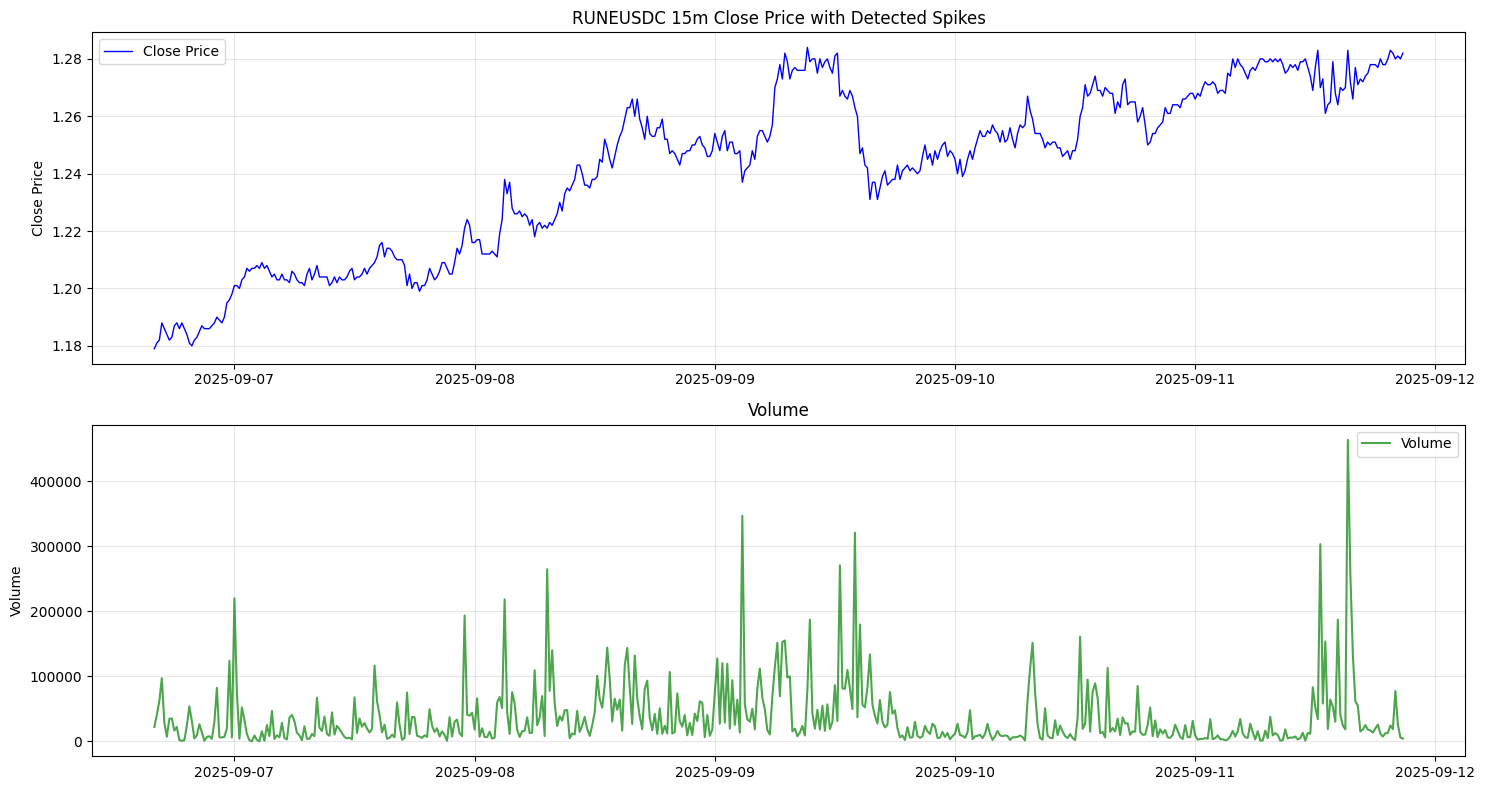

Total candles: 500
Spikes detected: 0
Detection rate: 0.0000

Price change statistics:
count    499.000000
mean       0.000172
std        0.002937
min       -0.011700
25%       -0.001582
50%        0.000000
75%        0.001662
max        0.011438
Name: price_change, dtype: float64

Volume ratio statistics:
count    489.000000
mean       1.030622
std        1.075328
min        0.001012
25%        0.334025
50%        0.682035
75%        1.296652
max        6.849561
Name: volume_ratio, dtype: float64

Candles with price_change > 0.021: 0
Candles with volume_ratio > 1.50: 104
Candles with BOTH > thresholds: 0

Top 5 price changes:
              timestamp  close  price_change  volume_ratio
140 2025-09-08 03:00:00  1.238      0.011438      4.971713
471 2025-09-11 13:45:00  1.279      0.011067      0.754068
248 2025-09-09 06:00:00  1.270      0.010342      2.102848
477 2025-09-11 15:15:00  1.283      0.010236      3.932875
480 2025-09-11 16:00:00  1.277      0.008689      0.545586

Top 5 volu

In [6]:
# === USAGE EXAMPLES ===
symbol = "RUNEUSDC"

# Set fixed thresholds for both training and production (example: 0.02 for price, 2.0 for volume)
FIXED_PRICE_THRESHOLD = 0.021
FIXED_VOLUME_THRESHOLD = 1.5

# Production analysis with fixed thresholds
hunter = SpikeHunter(
    model_path="../checkpoints/spikehunter_model_v1.pkl",
    price_threshold=FIXED_PRICE_THRESHOLD,
    volume_threshold=FIXED_VOLUME_THRESHOLD,
    # You can also set window/momentum_threshold/rsi_oversold if needed
    # window=12, momentum_threshold=0.012, rsi_oversold=30,
    )
df, summary = hunter.run_analysis(symbol=symbol)

time_windows = [5, 15, 30]
spike_found = False
for window in time_windows:
    last_spike = hunter.get_last_spike_details(df, symbol=symbol, max_minutes_ago=window)
    if last_spike:
        print(
            f"🔥 LAST SPIKE DETECTED (within {window} minutes)\n"
            f"📅 Time: {last_spike['timestamp'].strftime('%Y-%m-%d %H:%M')}\n"
            f"📈 Price: +{last_spike['price_change_pct']:.2f}%\n"
            f"📊 Volume: {last_spike['volume_ratio']:.1f}x above average\n"
            f"🏷️ Type: {last_spike['spike_type']}\n"
            f"⚡ Strength: {last_spike['signal_strength']:.1f}/10\n"
            f"⏰ Occurred: {last_spike['minutes_ago']:.1f} minutes ago"
        )
        spike_found = True
        break
if not spike_found:
    print(f"📊 No recent spikes detected in {symbol} within the last 30 minutes")
    all_spikes = df[df["spike_signal"] == 1]
    if len(all_spikes) > 0:
        last_any_spike = all_spikes.iloc[-1]
        minutes_ago = (
            pd.Timestamp.now(tz="UTC")
            - (last_any_spike["timestamp"].tz_localize("UTC") if last_any_spike["timestamp"].tz is None else last_any_spike["timestamp"])
).total_seconds() / 60
        print(
            f"💡 Last spike was {minutes_ago / 60:.1f} hours ago at {last_any_spike['timestamp'].strftime('%Y-%m-%d %H:%M')}"
        )

# Show detected spikes
detected_spikes = df[df["spike_signal"] == 1]
print(f"\n🔥 Detected {len(detected_spikes)} spikes for {symbol}:")
if not detected_spikes.empty:
    print(detected_spikes[["timestamp", "close", "price_change", "volume_ratio", "spike_type", "signal_strength"]].tail(10))
else:
    print(f"No spikes detected for {symbol}.")

# --- Plot detected spikes with dynamic thresholds ---
plt.figure(figsize=(15, 8))
# Price plot
plt.subplot(2, 1, 1)
plt.plot(df["timestamp"], df["close"], label="Close Price", color="blue", linewidth=1)
spike_indices = df.index[df["spike_signal"] == 1]
if len(spike_indices) > 0:
    plt.scatter(
        df.loc[spike_indices, "timestamp"],
        df.loc[spike_indices, "close"],
        color="red",
        label=f"Detected Spikes ({len(spike_indices)})",
        zorder=5,
        s=50,
    )
plt.title(f"{symbol} 15m Close Price with Detected Spikes")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True, alpha=0.3)
# Volume plot
plt.subplot(2, 1, 2)
plt.plot(df["timestamp"], df["volume"], label="Volume", color="green", alpha=0.7)
if len(spike_indices) > 0:
    plt.scatter(
        df.loc[spike_indices, "timestamp"],
        df.loc[spike_indices, "volume"],
        color="red",
        label="Spike Volume",
        zorder=5,
        s=50,
    )
plt.title("Volume")
plt.ylabel("Volume")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Additional stats and reporting ---
print(f"Total candles: {len(df)}")
print(f"Spikes detected: {len(detected_spikes)}")
if len(df) > 0:
    print(f"Detection rate: {len(detected_spikes)/len(df):.4f}")
print("\nPrice change statistics:")
print(df["price_change"].describe())
print("\nVolume ratio statistics:")
print(df["volume_ratio"].describe())
# Show how many candles exceed the thresholds
price_thresh = hunter.price_threshold
vol_thresh = hunter.volume_threshold
price_spikes = df[df["price_change"] > price_thresh]
vol_spikes = df[df["volume_ratio"] > vol_thresh]
both_spikes = df[(df["price_change"] > price_thresh) & (df["volume_ratio"] > vol_thresh)]
print(f"\nCandles with price_change > {price_thresh:.3f}: {len(price_spikes)}")
print(f"Candles with volume_ratio > {vol_thresh:.2f}: {len(vol_spikes)}")
print(f"Candles with BOTH > thresholds: {len(both_spikes)}")
print("\nTop 5 price changes:")
print(df.nlargest(5, "price_change")[["timestamp", "close", "price_change", "volume_ratio"]])
print("\nTop 5 volume ratios:")
print(df.nlargest(5, "volume_ratio")[["timestamp", "close", "price_change", "volume_ratio"]])
print("\nMean close price:", df["close"].mean())
print("Mean volume:", df["volume"].mean())
print("Std price_change:", df["price_change"].std())
print("Std volume_ratio:", df["volume_ratio"].std())
print("\nIf very few candles exceed the thresholds, consider lowering price_threshold or volume_threshold, or check if the symbol is inactive/illiquid.")


# --- Plotting: Three Types of Detected Spikes ---
if not detected_spikes.empty:
    plt.figure(figsize=(15, 10))
    # Price + Volume spikes
    pv_spikes = df[df['spike_type'] == 'price_volume']
    # Momentum spikes
    mom_spikes = df[df['spike_type'] == 'momentum']
    # RSI reversal spikes
    rsi_spikes = df[df['spike_type'] == 'rsi_reversal']

    plt.plot(df['timestamp'], df['close'], label='Close Price', color='blue', linewidth=1)
    if not pv_spikes.empty:
        plt.scatter(pv_spikes['timestamp'], pv_spikes['close'], color='red', label='Price+Volume Spikes', s=50, zorder=5)
    if not mom_spikes.empty:
        plt.scatter(mom_spikes['timestamp'], mom_spikes['close'], color='orange', label='Momentum Spikes', s=50, zorder=5)
    if not rsi_spikes.empty:
        plt.scatter(rsi_spikes['timestamp'], rsi_spikes['close'], color='purple', label='RSI Reversal Spikes', s=50, zorder=5)
    plt.title(f"{symbol} 15m Close Price with Spike Types")
    plt.xlabel('Timestamp')
    plt.ylabel('Close Price')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No spikes detected to plot by type.")
